In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from pyprojroot import here

import sys
sys.path.append(str(here("Scripts")))
from data_utils import sort_data

In [3]:
data_path = here("Data/FPL_data_tidy.parquet")
data = pd.read_parquet(data_path)

In [4]:
data.head()

,team_name,first_name,match_id,web_name,position,second_name,status,tackles_won_percent,xg,ground_duels_won,transfers_out_event,shots_on_target,now_cost,accurate_passes,now_cost_rank,headed_clearances,bonus,gk_accurate_long_balls,touches_opposition_box,saves,event_points,final_third_passes,accurate_crosses,team_goals_conceded,big_chances_missed,high_claim,cost_change_start,minutes_played,interceptions,aerial_duels_won,gk_accurate_passes,expected_goal_involvements,tackles_won,xgot_faced,touches,player_code,penalties_order,sweeper_actions,influence,ground_duels_won_percent,team_code,value_season,total_points,tackles,transfers_out,transfers_in,expected_assists,accurate_passes_percent,ep_next,fouls_committed,clearances,total_shots,selected_rank,recoveries,goals_conceded,duels_won,goals_prevented,transfers_in_event,ep_this,xa,finish_min,penalties_missed,xgot,id,duels_lost,chance_of_playing_next_round,ict_index,offsides,form,threat,cost_change_event,assists,chances_created,gw,selected_by_percent,direct_freekicks_order,successful_dribbles_percent,chance_of_playing_this_round,penalties_scored,accurate_long_balls,start_min,dreamteam_count,corners_and_indirect_freekicks_order,team_strength,successful_dribbles,creativity,was_fouled,bps,blocks,expected_goals_conceded,aerial_duels_won_percent,expected_goals,value_form,accurate_crosses_percent,dribbled_past,goals,accurate_long_balls_percent,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
0,Brighton,James,24-25-prem-everton-vs-brighton-&-hove-albion,Milner,MID,Milner,a,50,0.0,4,421,0,5.0,28,172,0,0,0,2,0,2,2,2,0,0,0,0,82,0,0,0,0.11,2,0.0,48,15157,6,0,22.4,80,36,0.4,2,4,421,513,0.11,85,1.6,1,0,0,471,0,0,4,0.0,513,1.6,0.11,82,0,0.0,134,2,0,7.0,0,2.0,4,0,0,3,1,0.1,7,0,0,0,1,0,0,1,3,0,43.8,0,10,2,0.45,0,0.0,0.4,29,0,0,33,2425,0.0,0.120732,0.120732,0.493902
1,Brighton,James,24-25-prem-brighton-&-hove-albion-vs-mancheste...,Milner,MID,Milner,a,0,0.16,3,635,1,5.0,22,177,0,0,0,2,0,2,6,1,1,0,0,0,73,1,0,0,0.31,0,0.0,42,15157,6,0,28.6,75,36,0.8,4,1,1548,2267,0.15,73,1.0,1,2,2,448,2,0,3,0.0,1189,2.0,0.04,73,0,0.0,134,1,0,10.7,0,2.0,12,0,0,1,2,0.1,7,100,0,0,0,0,0,1,3,1,66.2,1,22,0,1.77,0,0.16,0.4,100,0,0,0,2425,0.19726,0.049315,0.382192,2.182192
2,Brighton,James,24-25-prem-arsenal-vs-brighton-&-hove-albion,Milner,MID,Milner,d,0,0.0,0,1998,0,5.0,2,185,0,0,0,0,0,1,0,0,0,0,0,0,17,1,0,0,0.31,0,0.0,4,15157,6,0,28.6,0,36,1.0,5,0,4535,4199,0.15,100,1.7,1,0,0,461,0,0,0,0.0,472,0.7,0.0,17,0,0.0,134,1,75,10.7,0,1.7,12,0,0,0,3,0.1,7,0,0,0,0,0,0,1,3,0,66.3,0,24,0,1.98,0,0.16,0.3,0,0,0,0,2425,0.0,0.0,1.641176,10.482353
3,Brighton,James,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,Milner,MID,Milner,a,0,0.0,0,0,0,5.0,0,192,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0.31,0,0.0,1,15157,6,0,28.6,0,36,1.2,6,0,10991,5014,0.15,0,0.0,0,0,0,586,0,0,0,0.0,0,0.0,0.0,93,0,0.0,134,0,100,10.7,0,0.2,12,0,0,0,38,0.0,7,0,0,0,0,93,0,8,3,0,66.3,0,27,0,1.98,0,0.16,0.0,0,0,0,0,2425,0.0,0.0,27.9,178.2
4,Brighton,James,25-26-prem-brighton-hove-albion-vs-fulham,Milner,MID,Milner,a,0,0.0,0,497,0,4.9,1,283,0,0,0,0,0,1,0,0,1,0,0,-1,2,0,0,0,0.0,0,0.0,1,15157,1,0,0.0,0,36,3.1,1,0,20304,14413,0.0,0,-0.5,0,0,0,467,0,0,0,0.0,113,0.0,0.0,90,0,0.0,170,0,100,0.0,0,0.0,0,0,0,0,1,0.1,7,0,0,0,0,0,0,5,3,0,0.1,0,3,0,0.24,0,0.0,0.0,0,0,0,0,2526,0.0,0.0,0.0,10.8


In [5]:
data.isna().sum().sum()

np.int64(0)

In [6]:
target = ['event_points']

ema_cols = [
    'xg', 'expected_goals', 'xg_per_90', 'xgot', 'total_shots',
    'shots_on_target', 'touches_opposition_box', 'big_chances_missed',
    'threat', 'ict_index', 'xa', 'expected_assists', 'xa_per_90',
    'expected_goal_involvements', 'chances_created', 'creativity',
    'final_third_passes', 'accurate_crosses', 'successful_dribbles',
    'touches', 'accurate_passes', 'recoveries', 'tackles', 'tackles_won',
    'interceptions', 'blocks', 'clearances', 'duels_won', 'duels_lost',
    'ground_duels_won', 'aerial_duels_won', 'headed_clearances',
    'influence', 'bps', 'saves', 'goals_prevented', 'was_fouled',
    'high_claim', 'sweeper_actions', 'gk_accurate_passes',
    'gk_accurate_long_balls', 'accurate_long_balls', 'dribbled_past', 'expected_goal_involvements_per_90', 'expected_goals_conceded_per_90'
]

cols_to_lag = [
    'event_points', 'total_points', 'minutes_played', 'goals', 'assists',
    'bonus', 'goals_conceded', 'team_goals_conceded', 'penalties_missed',
    'penalties_scored', 'fouls_committed', 'offsides', 'start_min', 'finish_min'
]

static_cols = [
    'team_name', 'position', 'team_strength', 'now_cost', 'now_cost_rank',
    'status', 'chance_of_playing_next_round', 'chance_of_playing_this_round',
    'penalties_order', 'direct_freekicks_order', 'corners_and_indirect_freekicks_order',
    'selected_by_percent', 'selected_rank', 'transfers_in_event', 'transfers_out_event',
    'transfers_in', 'transfers_out', 'cost_change_event', 'cost_change_start',
    'value_form', 'value_season', 'form', 'ep_this', 'ep_next', 'dreamteam_count'
]

ratio_features = [
    'accurate_passes_percent', 'tackles_won_percent', 'aerial_duels_won_percent',
    'ground_duels_won_percent', 'successful_dribbles_percent',
    'accurate_crosses_percent', 'accurate_long_balls_percent',
    'expected_goals_conceded'
]

cols_id = [
    'id', 'player_code', 'web_name', 'first_name', 'second_name',
    'team_code', 'season_id', 'gw', 'match_id'
]

In [7]:
data.shape[1],  len(cols_to_lag + cols_id + ema_cols + static_cols+ ratio_features+target)

(102, 102)

In [8]:
def ema(df:pd.DataFrame,
        cols_to_lag:list[str] | None,
        window_size:int=4)->tuple[pd.DataFrame, list[str]]:

    if cols_to_lag is None:
        return df.copy(), []

    df = sort_data(df)

    ema_frame = df.groupby(["player_code", "season_id"])[cols_to_lag].transform(lambda x: x.ewm(span=window_size, adjust=False).mean().shift(1))

    new_cols = [f"{c}_ema_{window_size}" for c in cols_to_lag]
    df[new_cols] = ema_frame.fillna(0)
    return df.drop(columns=cols_to_lag), new_cols


In [9]:
def lagged_features(df:pd.DataFrame,
                    cols_to_lag:list[str] | None,
                    lag_size:int=1)->tuple[pd.DataFrame, list[str]]:
    if cols_to_lag is None:
        return df.copy(), []

    df = sort_data(df)

    lagged_frame = df.groupby(["player_code", "season_id"])[cols_to_lag].transform(lambda x: x.shift(lag_size))
    new_cols = [f"{c}_lagged_{lag_size}" for c in cols_to_lag]
    df[new_cols] = lagged_frame.fillna(0)

    return df.drop(columns=cols_to_lag), new_cols

In [10]:
data_ema, ema_cols = ema(df=data,
                        cols_to_lag=ema_cols,
                        window_size=4)


In [11]:
data.shape

(21629, 102)

In [12]:
data_ema.shape

(21629, 102)

In [13]:
data_lagged, lagged_cols = lagged_features(df=data_ema,
                        cols_to_lag=cols_to_lag)


In [14]:
data_lagged.shape

(21629, 102)

In [15]:
data_lagged.head()

,team_name,first_name,match_id,web_name,position,second_name,status,tackles_won_percent,transfers_out_event,now_cost,now_cost_rank,cost_change_start,xgot_faced,player_code,penalties_order,ground_duels_won_percent,team_code,value_season,transfers_out,transfers_in,accurate_passes_percent,ep_next,selected_rank,transfers_in_event,ep_this,id,chance_of_playing_next_round,form,cost_change_event,gw,selected_by_percent,direct_freekicks_order,successful_dribbles_percent,chance_of_playing_this_round,dreamteam_count,corners_and_indirect_freekicks_order,team_strength,expected_goals_conceded,aerial_duels_won_percent,value_form,accurate_crosses_percent,accurate_long_balls_percent,season_id,xg_ema_4,expected_goals_ema_4,xg_per_90_ema_4,xgot_ema_4,total_shots_ema_4,shots_on_target_ema_4,touches_opposition_box_ema_4,big_chances_missed_ema_4,threat_ema_4,ict_index_ema_4,xa_ema_4,expected_assists_ema_4,xa_per_90_ema_4,expected_goal_involvements_ema_4,chances_created_ema_4,creativity_ema_4,final_third_passes_ema_4,accurate_crosses_ema_4,successful_dribbles_ema_4,touches_ema_4,accurate_passes_ema_4,recoveries_ema_4,tackles_ema_4,tackles_won_ema_4,interceptions_ema_4,blocks_ema_4,clearances_ema_4,duels_won_ema_4,duels_lost_ema_4,ground_duels_won_ema_4,aerial_duels_won_ema_4,headed_clearances_ema_4,influence_ema_4,bps_ema_4,saves_ema_4,goals_prevented_ema_4,was_fouled_ema_4,high_claim_ema_4,sweeper_actions_ema_4,gk_accurate_passes_ema_4,gk_accurate_long_balls_ema_4,accurate_long_balls_ema_4,dribbled_past_ema_4,expected_goal_involvements_per_90_ema_4,expected_goals_conceded_per_90_ema_4,event_points_lagged_1,total_points_lagged_1,minutes_played_lagged_1,goals_lagged_1,assists_lagged_1,bonus_lagged_1,goals_conceded_lagged_1,team_goals_conceded_lagged_1,penalties_missed_lagged_1,penalties_scored_lagged_1,fouls_committed_lagged_1,offsides_lagged_1,start_min_lagged_1,finish_min_lagged_1
0,Brighton,James,24-25-prem-everton-vs-brighton-&-hove-albion,Milner,MID,Milner,a,50,421,5.0,172,0,0.0,15157,6,80,36,0.4,421,513,85,1.6,471,513,1.6,134,0,2.0,0,1,0.1,7,0,0,0,1,3,0.45,0,0.4,29,33,2425,0.0000,0.0000,0.000000,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0000,0.0000,0.000000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.000,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Brighton,James,24-25-prem-brighton-&-hove-albion-vs-mancheste...,Milner,MID,Milner,a,0,635,5.0,177,0,0.0,15157,6,75,36,0.8,1548,2267,73,1.0,448,1189,2.0,134,0,2.0,0,2,0.1,7,100,0,0,1,3,1.77,0,0.4,100,0,2425,0.0000,0.0000,0.000000,0.0,0.00,0.00,2.0,0.0,4.00,7.000,0.1100,0.1100,0.120732,0.110,3.00,43.800,2.00,2.00,0.00,48.00,28.00,0.00,4.00,2.00,0.00,2.00,0.00,4.00,2.00,4.00,0.0,0.0,22.400,10.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1.00,0.0,0.120732,0.493902,2,2,82,0,0,0,0,0,0,0,1,0,0,82
2,Brighton,James,24-25-prem-arsenal-vs-brighton-&-hove-albion,Milner,MID,Milner,d,0,1998,5.0,185,0,0.0,15157,6,0,36,1.0,4535,4199,100,1.7,461,472,0.7,134,75,1.7,0,3,0.1,7,0,0,0,1,3,1.98,0,0.3,0,0,2425,0.0640,0.0640,0.078904,0.0,0.80,0.40,2.0,0.0,7.20,8.480,0.0820,0.1260,0.092165,0.190,2.20,52.760,3.60,1.60,0.40,45.60,25.60,0.80,2.80,1.20,0.40,1.20,0.80,3.60,1.60,3.60,0.0,0.0,24.880,14.80,0.0,0.0,0.40,0.0,0.0,0.0,0.0,0.60,0.0,0.225316,1.169218,2,4,73,0,0,0,0,1,0,0,1,0,0,73
3,Brighton,James,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,Milner,MID,Milner,a,0,0,5.0,192,0,0.0,15157,6,0,36,1.2,10991,5014,0,0.0,586,0,0.0,134,100,0.2,0,38,0.0,7,0,0,0,8,3,1.98,0,0.0,0,0,2425,0.0384,0.1024,0.047342,0.0,0.48,0.24,1.2,0.0,9.12,9.368,0.0492,0.1356,0.055299,0.238,1.32,58.176,2.16,0.96,0.24,28.96,16.16,0.48,1.68,0.72,0.64,0.72,0.48,2.16,1.36,2.16,0.0,0.0,26.368,18.48,0.0,0.0,0.24,0.0,0.0,0.0,0.0,0.36,0.0,0.791660,4.894472,1,5,17,0,0,0,0,0,0,0,1,0,0,17
4,Brighton,James,25-26-prem-brighton-hove-albion-vs-fulham,Milner,MID,Milner,a,0,497,4.9,283,-1,0.0,15157,1,0,36,3.1,20304,14413,0,-0.5,467,113,0.0,170,100,0.0,0,1,0.1,7,0,0,0,5,3,0.24,0,0.0,0,0,2526,

In [16]:
data_lagged["event_points"] = data.event_points

In [17]:
data_lagged.shape

(21629, 103)

In [18]:
cols_to_drop = [
    # Identyfikatory
    'first_name', 'second_name',
    'expected_goals_conceded', 'xgot_faced',
    'ep_this', 'ep_next', 'form', 'value_form', 'value_season',
    'transfers_in', 'transfers_out', 'transfers_in_event',
    'transfers_out_event', 'now_cost_rank', 'selected_rank',
    'cost_change_event', 'cost_change_start',
    'tackles_won_percent', 'ground_duels_won_percent',
    'accurate_passes_percent', 'successful_dribbles_percent',
    'aerial_duels_won_percent', 'accurate_crosses_percent',
    'accurate_long_balls_percent'
]

# Aby przygotować dane do X i y:
# X = df.drop(columns=cols_to_drop + ['event_points'])
# y = df['event_points']

In [19]:
data_lagged.drop(columns=cols_to_drop, inplace=True)

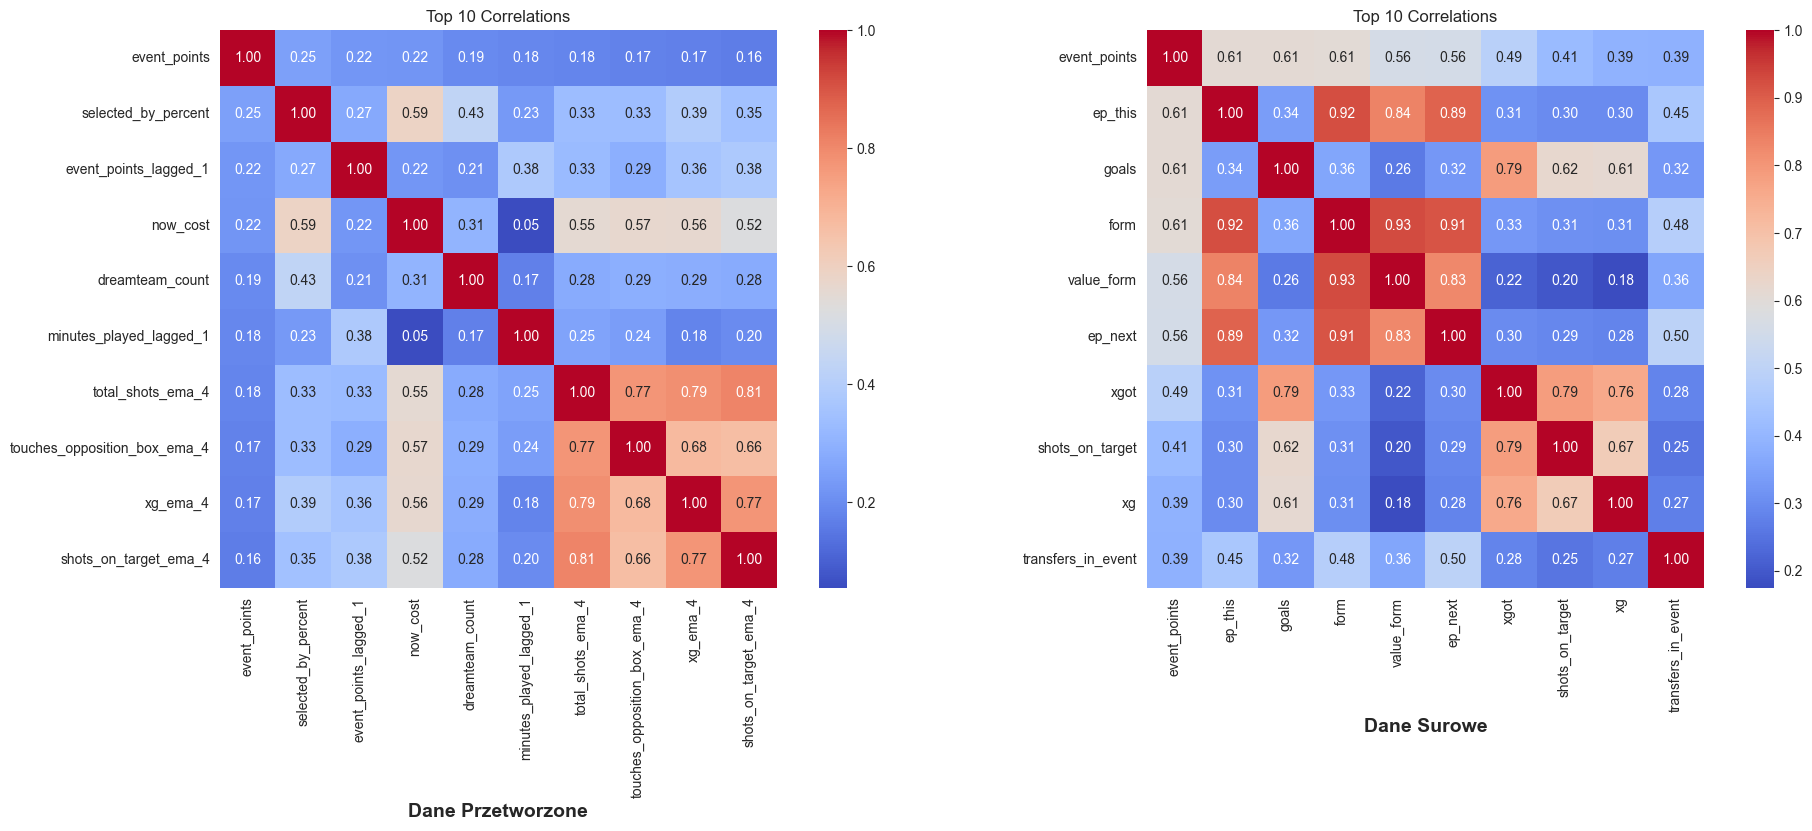

In [20]:
def corr_heatmaps(frames: list[pd.DataFrame], titles: list[str]) -> plt.Figure:
    fig, axes = plt.subplots(1, len(frames), figsize=(10 * len(frames), 8))
    if len(frames) == 1: axes = [axes]

    for ax, df, title in zip(axes, frames, titles):
        top_cols = df.select_dtypes(include=np.number).corr()["event_points"].abs().nlargest(10).index

        sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm", ax=ax,
                    square=True, fmt=".2f")

        ax.set_yticklabels(ax.get_yticklabels(), rotation=0) # Etykiety Y poziomo
        ax.set_title(f"Top 10 Correlations")
        ax.set_xlabel(title, fontsize=14, fontweight='bold') # Podpis pod wykresem

    plt.tight_layout()
    return fig

fig = corr_heatmaps([data_lagged, data], ["Dane Przetworzone", "Dane Surowe"])

In [21]:
def over_corr_pairs(df: pd.DataFrame, threshold: float = 0.9) -> list[tuple[str, str, float]]:
    corr_matrix = df.select_dtypes(include=np.number).corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    pairs = []
    for col in upper_tri.columns:
        correlated_with = upper_tri[col][upper_tri[col] > threshold]
        for idx, val in correlated_with.items():
            pairs.append((idx, col, round(val, 4)))

    return pairs

# for p in pairs: print(f"{p[0]} <-> {p[1]}: {p[2]}")

In [22]:
pairs = over_corr_pairs(data_lagged, 0.9)
pairs

[('chance_of_playing_next_round', 'chance_of_playing_this_round', 0.9516),
 ('expected_goals_ema_4', 'threat_ema_4', 0.9546),
 ('expected_goals_ema_4', 'expected_goal_involvements_ema_4', 0.9553),
 ('threat_ema_4', 'expected_goal_involvements_ema_4', 0.9607),
 ('ict_index_ema_4', 'expected_goal_involvements_ema_4', 0.9239),
 ('ict_index_ema_4', 'creativity_ema_4', 0.9037),
 ('expected_assists_ema_4', 'creativity_ema_4', 0.9585),
 ('touches_ema_4', 'accurate_passes_ema_4', 0.9447),
 ('clearances_ema_4', 'headed_clearances_ema_4', 0.9219),
 ('ict_index_ema_4', 'influence_ema_4', 0.9121),
 ('ict_index_ema_4', 'bps_ema_4', 0.951),
 ('influence_ema_4', 'bps_ema_4', 0.9459),
 ('ict_index_ema_4', 'total_points_lagged_1', 0.9533),
 ('influence_ema_4', 'total_points_lagged_1', 0.9414),
 ('bps_ema_4', 'total_points_lagged_1', 0.9728)]

In [23]:
for col1, col2, _ in pairs:
    if col1 in data_lagged.columns and col2 in data_lagged.columns:
        data_lagged.drop(columns=col1, inplace=True)

In [24]:
data_lagged.shape

(21629, 70)

In [25]:
data_lagged.head()

,team_name,match_id,web_name,position,status,now_cost,player_code,penalties_order,team_code,id,gw,selected_by_percent,direct_freekicks_order,chance_of_playing_this_round,dreamteam_count,corners_and_indirect_freekicks_order,team_strength,season_id,xg_ema_4,xg_per_90_ema_4,xgot_ema_4,total_shots_ema_4,shots_on_target_ema_4,touches_opposition_box_ema_4,big_chances_missed_ema_4,xa_ema_4,xa_per_90_ema_4,expected_goal_involvements_ema_4,chances_created_ema_4,creativity_ema_4,final_third_passes_ema_4,accurate_crosses_ema_4,successful_dribbles_ema_4,accurate_passes_ema_4,recoveries_ema_4,tackles_ema_4,tackles_won_ema_4,interceptions_ema_4,blocks_ema_4,duels_won_ema_4,duels_lost_ema_4,ground_duels_won_ema_4,aerial_duels_won_ema_4,headed_clearances_ema_4,saves_ema_4,goals_prevented_ema_4,was_fouled_ema_4,high_claim_ema_4,sweeper_actions_ema_4,gk_accurate_passes_ema_4,gk_accurate_long_balls_ema_4,accurate_long_balls_ema_4,dribbled_past_ema_4,expected_goal_involvements_per_90_ema_4,expected_goals_conceded_per_90_ema_4,event_points_lagged_1,total_points_lagged_1,minutes_played_lagged_1,goals_lagged_1,assists_lagged_1,bonus_lagged_1,goals_conceded_lagged_1,team_goals_conceded_lagged_1,penalties_missed_lagged_1,penalties_scored_lagged_1,fouls_committed_lagged_1,offsides_lagged_1,start_min_lagged_1,finish_min_lagged_1,event_points
0,Brighton,24-25-prem-everton-vs-brighton-&-hove-albion,Milner,MID,a,5.0,15157,6,36,134,1,0.1,7,0,0,1,3,2425,0.0000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0000,0.000000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
1,Brighton,24-25-prem-brighton-&-hove-albion-vs-mancheste...,Milner,MID,a,5.0,15157,6,36,134,2,0.1,7,0,0,1,3,2425,0.0000,0.000000,0.0,0.00,0.00,2.0,0.0,0.1100,0.120732,0.110,3.00,43.800,2.00,2.00,0.00,28.00,0.00,4.00,2.00,0.00,2.00,4.00,2.00,4.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1.00,0.0,0.120732,0.493902,2,2,82,0,0,0,0,0,0,0,1,0,0,82,2
2,Brighton,24-25-prem-arsenal-vs-brighton-&-hove-albion,Milner,MID,d,5.0,15157,6,36,134,3,0.1,7,0,0,1,3,2425,0.0640,0.078904,0.0,0.80,0.40,2.0,0.0,0.0820,0.092165,0.190,2.20,52.760,3.60,1.60,0.40,25.60,0.80,2.80,1.20,0.40,1.20,3.60,1.60,3.60,0.0,0.0,0.0,0.0,0.40,0.0,0.0,0.0,0.0,0.60,0.0,0.225316,1.169218,2,4,73,0,0,0,0,1,0,0,1,0,0,73,1
3,Brighton,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,Milner,MID,a,5.0,15157,6,36,134,38,0.0,7,0,0,8,3,2425,0.0384,0.047342,0.0,0.48,0.24,1.2,0.0,0.0492,0.055299,0.238,1.32,58.176,2.16,0.96,0.24,16.16,0.48,1.68,0.72,0.64,0.72,2.16,1.36,2.16,0.0,0.0,0.0,0.0,0.24,0.0,0.0,0.0,0.0,0.36,0.0,0.791660,4.894472,1,5,17,0,0,0,0,0,0,0,1,0,0,17,1
4,Brighton,25-26-prem-brighton-hove-albion-vs-fulham,Milner,MID,a,4.9,15157,1,36,170,1,0.1,7,0,0,5,3,2526,0.0000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0000,0.000000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [26]:
filename = "../../Data/FPL_data.parquet"
data_lagged.to_parquet(filename,
                engine='pyarrow',
                index=False)

In [27]:
data[data.season_id==2526].gw.unique()

<IntegerArray>
[ 1,  3,  4,  5,  6,  7,  8,  9, 16, 17, 19, 20, 21, 23, 24, 26,  2, 10, 11,
 12, 13, 14, 15, 18, 22, 25, 27]
Length: 27, dtype: Int64